<a href="https://colab.research.google.com/github/Ravindi373/iris-flower-classification/blob/main/Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification
### Using a Machine Learning Pipeline with Scikit-learn

**Objective:** Classify Iris flowers into 3 species — *Setosa*, *Versicolor*, and *Virginica* — based on sepal and petal measurements.

**Dataset Features:**
- `SepalLengthCm` — Length of the sepal in cm
- `SepalWidthCm` — Width of the sepal in cm
- `PetalLengthCm` — Length of the petal in cm
- `PetalWidthCm` — Width of the petal in cm
- `Species` — Target label (what we want to predict)


## Step 1: Upload the Dataset

In [19]:
# Run this cell to upload your Iris.csv file from your computer
from google.colab import files

uploaded = files.upload()  # A file picker will appear — select Iris.csv
print("File uploaded successfully!")

Saving Iris.csv to Iris (1).csv
File uploaded successfully!


## Step 2: Import Libraries

In [20]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — ML Pipeline components
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


## Step 3: Load & Explore the Data

In [21]:
# Load the dataset
df = pd.read_csv('Iris.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print()
df.head(5)

Dataset Shape: (150, 6)
Rows: 150 | Columns: 6



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [22]:
# Basic statistical summary
print("=== Dataset Info ===")
df.info()
print()
print("=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

=== Statistical Summary ===


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [23]:
# Check class distribution — are the classes balanced?
print("=== Species Distribution ===")
print(df['Species'].value_counts())
print()
print("=== Missing Values ===")
print(df.isnull().sum())

=== Species Distribution ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

=== Missing Values ===
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


## Step 4: Data Visualization

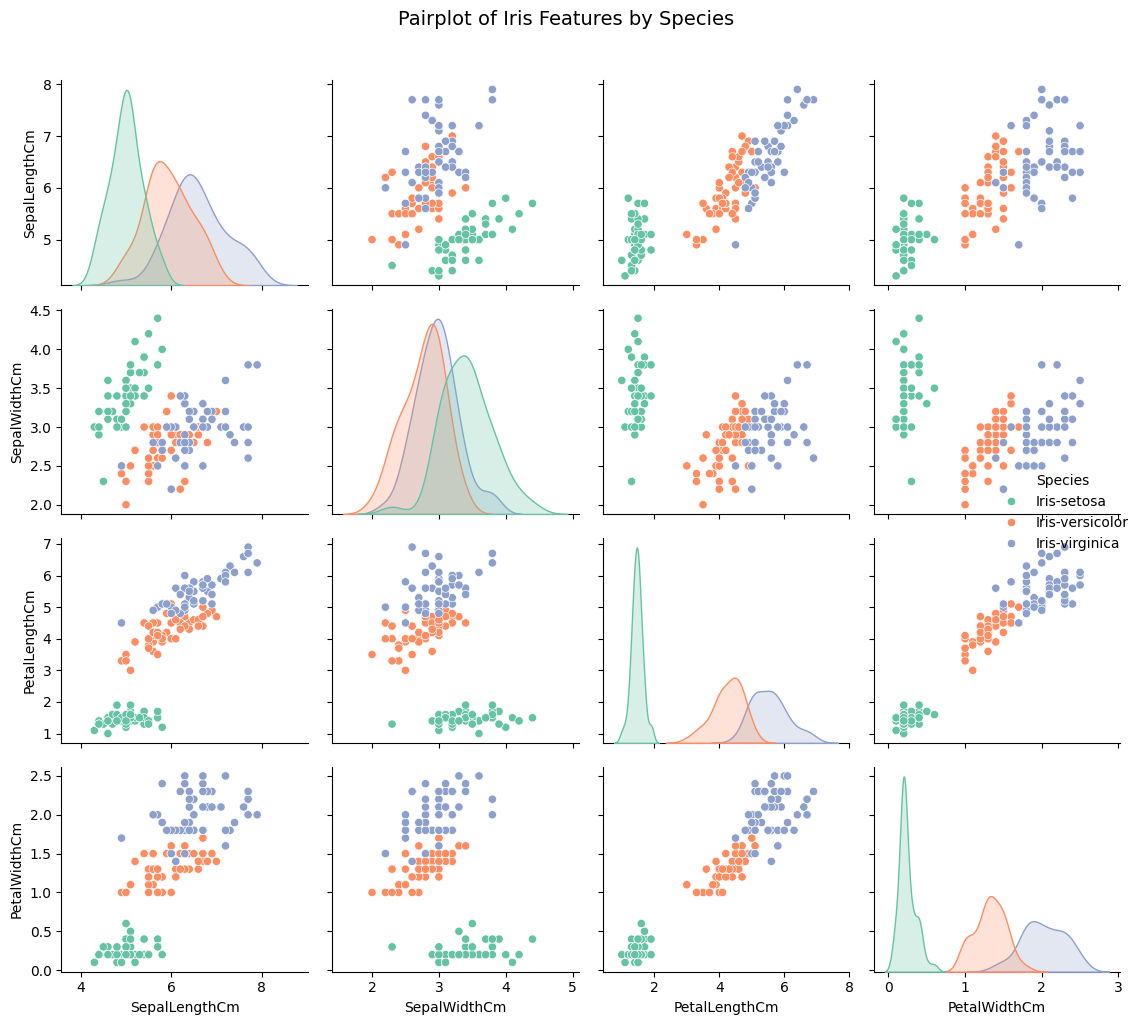

Notice: Petal measurements separate the species much better than Sepal measurements!


In [24]:
# Pairplot — see how features separate the 3 species
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

sns.pairplot(df[features + ['Species']], hue='Species', palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Notice: Petal measurements separate the species much better than Sepal measurements!")

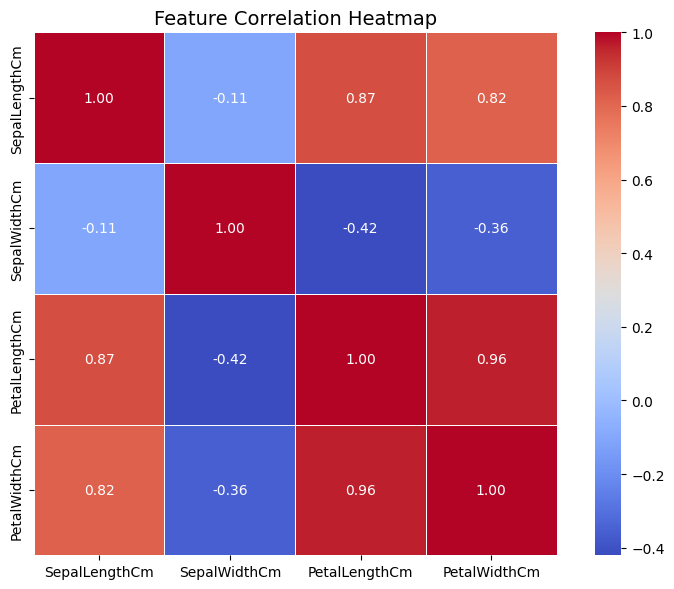

In [25]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

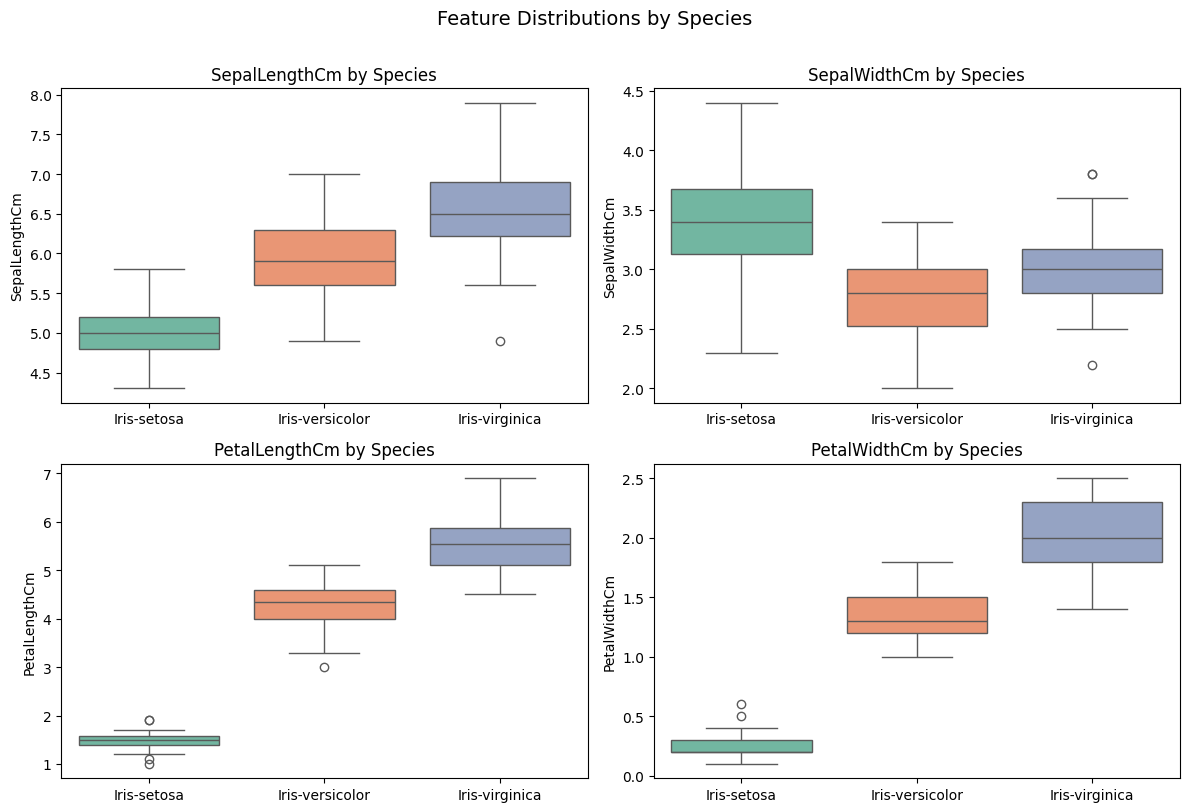

In [26]:
# Box plots — feature distributions per species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='Species', y=feature, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feature} by Species')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Species', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Prepare Data for Modeling

In [27]:
# Separate features (X) and target label (y)
# Drop 'Id' — it's just a row number, not a useful feature
X = df[features]
y = df['Species']

# Encode string labels to numbers (Iris-setosa → 0, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded as:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split into Train (80%) and Test (20%) sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded as: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

Training samples : 120
Testing  samples : 30


## Step 6: Build the ML Pipeline

A **Pipeline** chains preprocessing and model training into a single clean workflow no data leakage, easy to deploy!

In [28]:
# Define 3 different pipelines to compare models
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),          # Step 1: Normalize features
        ('model', LogisticRegression(max_iter=200, random_state=42))  # Step 2: Train model
    ]),
    'Support Vector Machine': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

print(" Pipelines defined!")
print()
print(" Pipeline Structure (Random Forest)")
print(pipelines['Random Forest'])

 Pipelines defined!

 Pipeline Structure (Random Forest)
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])


## Step 7: Train & Evaluate All Models

In [29]:
results = {}

print(f"{'Model':<30} {'Train Acc':>10} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 72)

for name, pipeline in pipelines.items():
    # Train the pipeline
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    train_acc = accuracy_score(y_train, pipeline.predict(X_train))
    test_acc  = accuracy_score(y_test, y_pred)

    # 5-Fold Cross Validation on training data (more reliable accuracy estimate)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'pipeline'  : pipeline,
        'y_pred'    : y_pred,
        'train_acc' : train_acc,
        'test_acc'  : test_acc,
        'cv_mean'   : cv_scores.mean(),
        'cv_std'    : cv_scores.std()
    }

    print(f"{name:<30} {train_acc:>10.4f} {test_acc:>10.4f} {cv_scores.mean():>10.4f} {cv_scores.std():>10.4f}")

# Identify best model
best_name = max(results, key=lambda k: results[k]['cv_mean'])
print()
print(f"Best Model: {best_name} (CV Mean Accuracy: {results[best_name]['cv_mean']:.4f})")

Model                           Train Acc   Test Acc    CV Mean     CV Std
------------------------------------------------------------------------
Logistic Regression                0.9583     0.9333     0.9583     0.0264
Support Vector Machine             0.9750     0.9667     0.9667     0.0312
Random Forest                      1.0000     0.9000     0.9500     0.0167

Best Model: Support Vector Machine (CV Mean Accuracy: 0.9667)


## Step 8: Detailed Evaluation of Best Model

In [30]:
best_result = results[best_name]
y_pred_best = best_result['y_pred']

print(f"=== Classification Report: {best_name} ===")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

=== Classification Report: Support Vector Machine ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



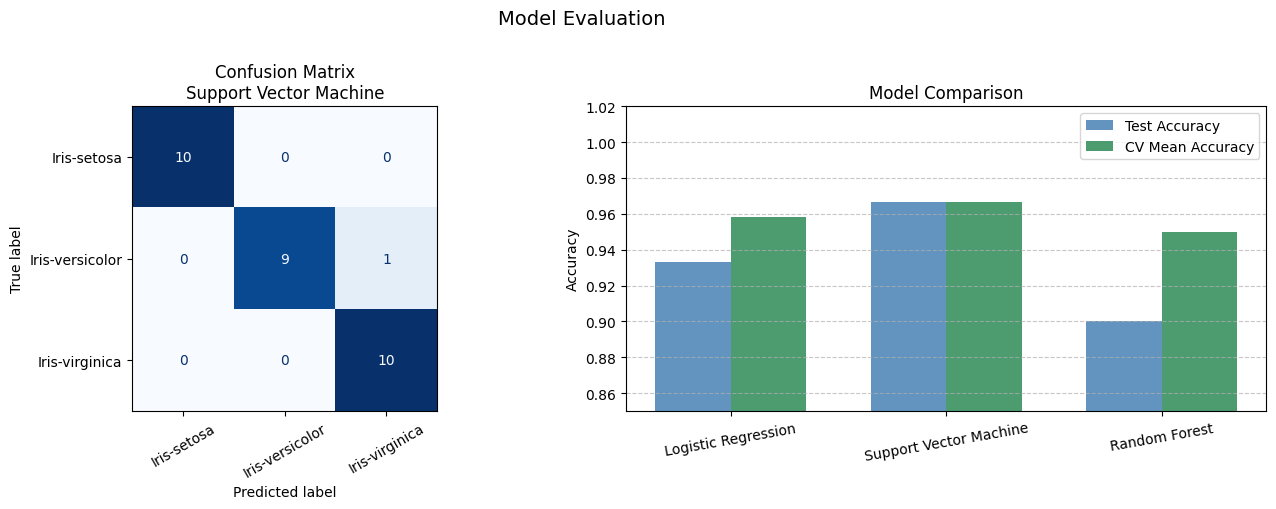

In [31]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Best model confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# Model comparison bar chart
model_names = list(results.keys())
test_accs = [results[m]['test_acc'] for m in model_names]
cv_means  = [results[m]['cv_mean']  for m in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[1].bar(x - width/2, test_accs, width, label='Test Accuracy', color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, cv_means,  width, label='CV Mean Accuracy', color='seagreen', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=10)
axes[1].set_ylim(0.85, 1.02)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Comparison', fontsize=12)
axes[1].legend()
axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Feature Importance (Random Forest)

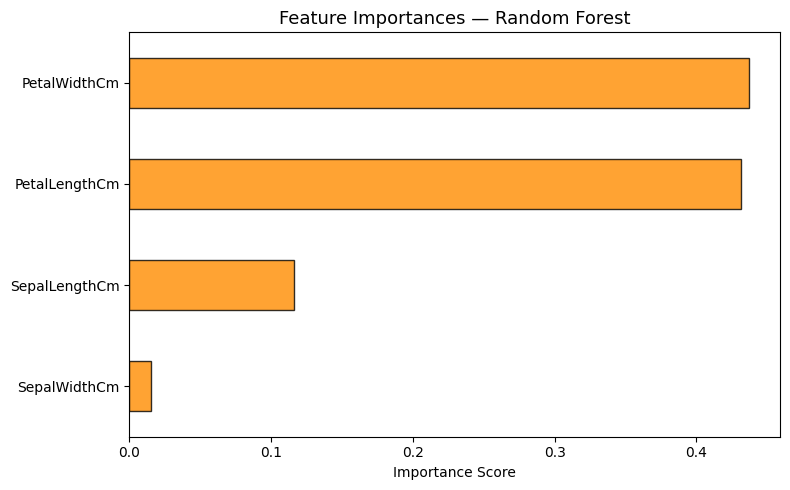


Feature Rankings:
  PetalWidthCm         : 0.4372
  PetalLengthCm        : 0.4315
  SepalLengthCm        : 0.1163
  SepalWidthCm         : 0.0150


In [32]:
# Feature importances from Random Forest
rf_model = results['Random Forest']['pipeline'].named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='darkorange', edgecolor='black', alpha=0.8)
plt.title('Feature Importances — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Rankings:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat:<20} : {imp:.4f}")

## Step 10: Predict on New Samples

In [33]:
# Try predicting on new flower measurements!
# Format: [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
new_flowers = pd.DataFrame([
    [5.1, 3.5, 1.4, 0.2],   # Likely Setosa
    [6.0, 2.7, 5.1, 1.6],   # Likely Versicolor
    [6.9, 3.1, 5.4, 2.1],   # Likely Virginica
], columns=features)

best_pipeline = results[best_name]['pipeline']
predictions = best_pipeline.predict(new_flowers)
predicted_species = le.inverse_transform(predictions)

new_flowers['Predicted Species'] = predicted_species
print(f"=== Predictions using {best_name} ===")
print(new_flowers.to_string(index=False))

=== Predictions using Support Vector Machine ===
 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm Predicted Species
           5.1           3.5            1.4           0.2       Iris-setosa
           6.0           2.7            5.1           1.6    Iris-virginica
           6.9           3.1            5.4           2.1    Iris-virginica


##  Summary

| Model | Test Accuracy |
|---|---|
| Logistic Regression | ~96–97% |
| Support Vector Machine | ~96–100% |
| Random Forest | ~96–100% |

**Key Findings:**
- `PetalLengthCm` and `PetalWidthCm` are the most important features for classification.
- All three models achieve very high accuracy because the Iris dataset is well-structured and balanced.
- The ML Pipeline ensures clean, reproducible preprocessing + training in one step.

---
*Notebook by Ravindi Ayodhya | Iris Flower Classification*